In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### Read csv file
df=pd.read_csv(r"D:\dataanalytics\Data\covid.csv")
df.head()

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region,iso_alpha
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas,USA
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas,BRA
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia,IND
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe,RUS
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa,ZAF


In [3]:
df.shape

(209, 17)

In [4]:
df.dtypes

Country/Region       object
Continent            object
Population          float64
TotalCases            int64
NewCases            float64
TotalDeaths         float64
NewDeaths           float64
TotalRecovered      float64
NewRecovered        float64
ActiveCases         float64
Serious,Critical    float64
Tot Cases/1M pop    float64
Deaths/1M pop       float64
TotalTests          float64
Tests/1M pop        float64
WHO Region           object
iso_alpha            object
dtype: object

In [6]:
df.columns

Index(['Country/Region', 'Continent', 'Population', 'TotalCases', 'NewCases',
       'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered',
       'ActiveCases', 'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop',
       'TotalTests', 'Tests/1M pop', 'WHO Region', 'iso_alpha'],
      dtype='object')

In [9]:
### Detecting noisy data
unique_value={}
for col in df.columns:
    unique_value[col]=df[col].unique()
print(unique_value)

{'Country/Region': array(['USA', 'Brazil', 'India', 'Russia', 'South Africa', 'Mexico',
       'Peru', 'Chile', 'Colombia', 'Spain', 'Iran', 'UK', 'Saudi Arabia',
       'Pakistan', 'Bangladesh', 'Italy', 'Turkey', 'Argentina',
       'Germany', 'France', 'Iraq', 'Philippines', 'Indonesia', 'Canada',
       'Qatar', 'Kazakhstan', 'Egypt', 'Ecuador', 'Bolivia', 'Sweden',
       'Oman', 'Israel', 'Ukraine', 'Dominican Republic', 'Panama',
       'Belgium', 'Kuwait', 'Belarus', 'UAE', 'Romania', 'Netherlands',
       'Singapore', 'Guatemala', 'Portugal', 'Poland', 'Nigeria',
       'Honduras', 'Bahrain', 'Japan', 'Armenia', 'Ghana', 'Kyrgyzstan',
       'Afghanistan', 'Switzerland', 'Algeria', 'Azerbaijan', 'Morocco',
       'Uzbekistan', 'Serbia', 'Moldova', 'Ireland', 'Kenya', 'Venezuela',
       'Nepal', 'Austria', 'Costa Rica', 'Ethiopia', 'Australia',
       'El Salvador', 'Czechia', 'Cameroon', 'Ivory Coast', 'S. Korea',
       'Denmark', 'Palestine', 'Bosnia and Herzegovina', 'Bulg

#### There is no unique value in the dataset

In [10]:
#### Detecting duplicate value
df.duplicated().sum()

np.int64(0)

In [11]:
#### There is no duplicated values

In [13]:
#### Detecting null values
df.isnull().sum()

Country/Region        0
Continent             1
Population            1
TotalCases            0
NewCases            205
TotalDeaths          21
NewDeaths           206
TotalRecovered        4
NewRecovered        206
ActiveCases           4
Serious,Critical     87
Tot Cases/1M pop      1
Deaths/1M pop        22
TotalTests           18
Tests/1M pop         18
WHO Region           25
iso_alpha             0
dtype: int64

In [14]:
### Drop missing value
df.drop(['NewCases','NewDeaths','NewRecovered'],axis=1,inplace=True)

In [16]:
df.columns


Index(['Country/Region', 'Continent', 'Population', 'TotalCases',
       'TotalDeaths', 'TotalRecovered', 'ActiveCases', 'Serious,Critical',
       'Tot Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop',
       'WHO Region', 'iso_alpha'],
      dtype='object')

In [25]:
df.describe()

,Population,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop
count,2.080000e+02,2.090000e+02,188.000000,2.050000e+02,2.050000e+02,122.000000,208.000000,187.000000,1.910000e+02,191.000000
mean,3.041549e+07,9.171850e+04,3792.590426,5.887898e+04,2.766433e+04,534.393443,3196.024038,98.681176,1.402405e+06,83959.366492
std,1.047661e+08,4.325867e+05,15487.184877,2.566984e+05,1.746327e+05,2047.518613,5191.986457,174.956862,5.553367e+06,152730.591240
min,8.010000e+02,1.000000e+01,1.000000,7.000000e+00,0.000000e+00,1.000000,3.000000,0.080000,6.100000e+01,4.000000
25%,9.663140e+05,7.120000e+02,22.000000,3.340000e+02,8.600000e+01,3.250000,282.000000,6.000000,2.575200e+04,8956.500000
50%,7.041972e+06,4.491000e+03,113.000000,2.178000e+03,8.990000e+02,27.500000,1015.000000,29.000000,1.357020e+05,32585.000000
75%,2.575614e+07,3.689600e+04,786.000000,2.055300e+04,7.124000e+03,160.250000,3841.750000,98.000000,7.576960e+05,92154.500000
max,1.381345e+09,5.032179e+06,162804.000000,2.576668e+06,2.292707e+06,18296.000000,39922.000000,1238.000000,6.313960e+07,995282.000000


In [26]:
### filling missing values
df['Continent']=df['Continent'].fillna(df['Continent'].mode()[0])
df['Population']=df['Population'].fillna(df['Population'].median())
df['TotalDeaths']=df['TotalDeaths'].fillna(df['TotalDeaths'].median())
df['TotalRecovered']=df['TotalRecovered'].fillna(df['TotalRecovered'].median())
df['ActiveCases']=df['ActiveCases'].fillna(df['ActiveCases'].median())
df['Serious,Critical']=df['Serious,Critical'].fillna(df['Serious,Critical'].median())
df['Tot Cases/1M pop']=df['Tot Cases/1M pop'].fillna(df['Tot Cases/1M pop'].median())
df['Deaths/1M pop']=df['Deaths/1M pop'].fillna(df['Deaths/1M pop'].median())
df['TotalTests']=df['TotalTests'].fillna(df['TotalTests'].median())
df['Tests/1M pop']=df['Tests/1M pop'].fillna(df['Tests/1M pop'].median())
df['WHO Region']=df['WHO Region'].fillna(df['WHO Region'].mode()[0])

In [27]:
df.isnull().sum()

Country/Region      0
Continent           0
Population          0
TotalCases          0
TotalDeaths         0
TotalRecovered      0
ActiveCases         0
Serious,Critical    0
Tot Cases/1M pop    0
Deaths/1M pop       0
TotalTests          0
Tests/1M pop        0
WHO Region          0
iso_alpha           0
dtype: int64

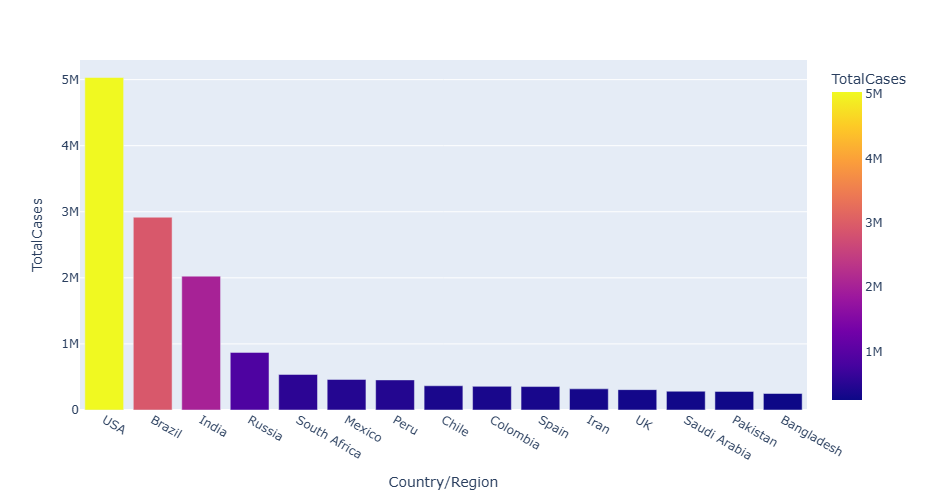

In [30]:
####Bar graphs- Comparisons between COVID infected countries in terms of total cases, total deaths,
###total recovered & total tests
import plotly.express as px
px.bar(df.head(15), x = 'Country/Region', 
       y = 'TotalCases',color = 'TotalCases', 
       height = 500,hover_data = ['Country/Region', 'Continent'])

<BarContainer object of 209 artists>

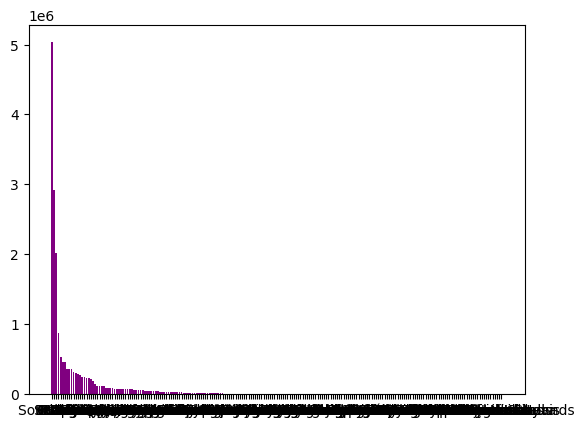

In [39]:
### Country wise population
plt.bar(df['Country/Region'],df['TotalCases'],color='purple')

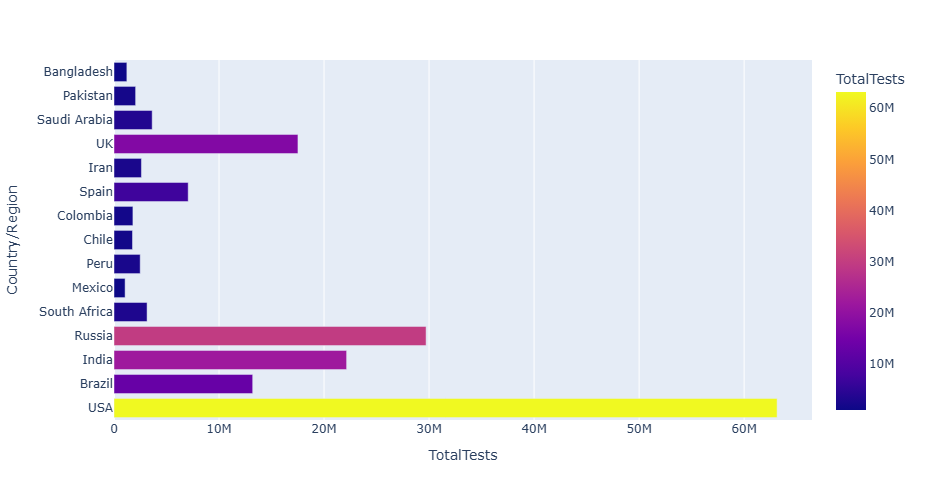

In [41]:
px.bar(df.head(15), x = 'TotalTests', y = 'Country/Region',
       color = 'TotalTests',orientation ='h',  height = 500,
       hover_data = ['Country/Region', 'Continent'])

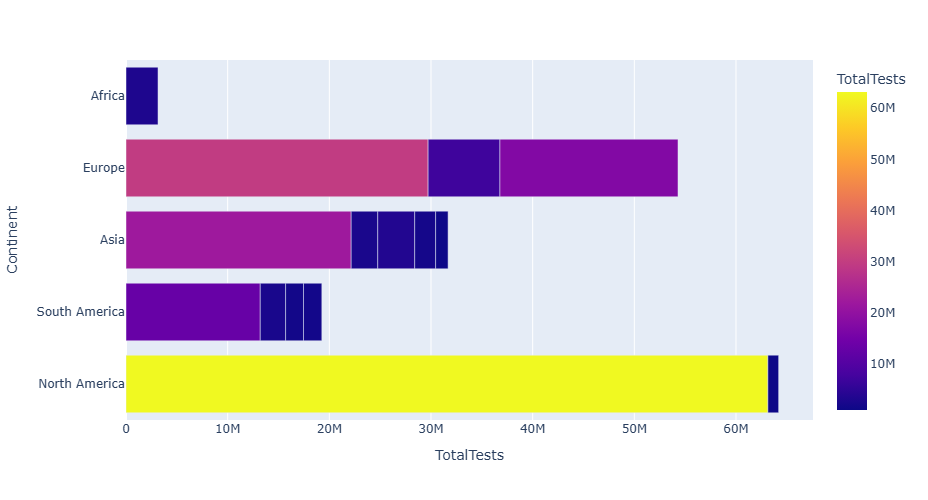

In [44]:
px.bar(df.head(15), x = 'TotalTests', y = 'Continent',
       color = 'TotalTests',orientation ='h',  height = 500,
       hover_data = ['Country/Region', 'Continent'])

#### Data Visualization through Bubble Charts-Continent Wise

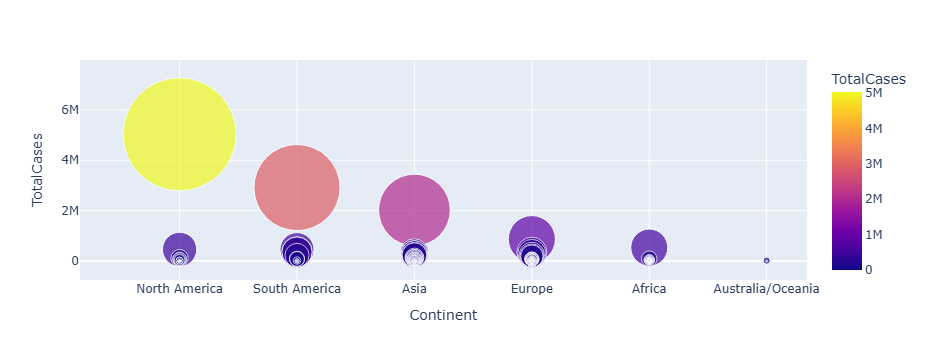

In [45]:
px.scatter(df, x='Continent',y='TotalCases', 
           hover_data=['Country/Region', 'Continent'], 
           color='TotalCases', size='TotalCases', size_max=80)

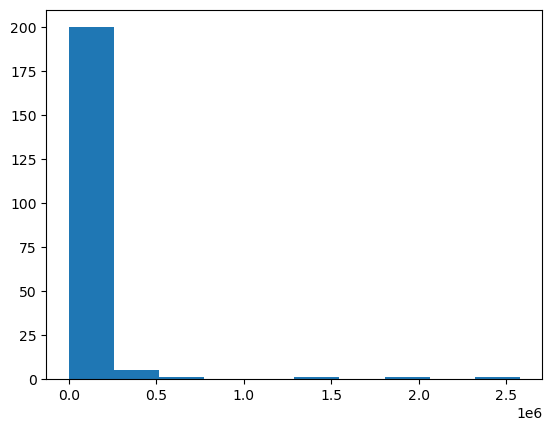

In [47]:
### how much frequency of total recoverd
plt.hist(df['TotalRecovered'])
plt.show()

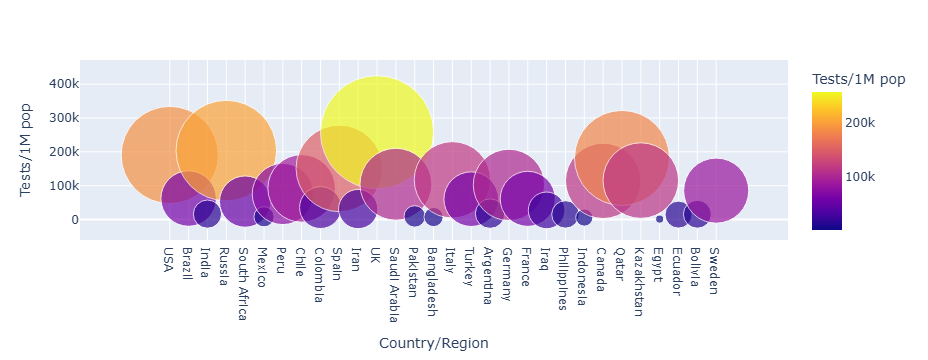

In [49]:
#### Data Visualization through Bubble Charts-Country Wise
px.scatter(df.head(30), x='Country/Region', y= 'Tests/1M pop', 
           hover_data=['Country/Region', 'Continent'],
           color='Tests/1M pop', size= 'Tests/1M pop', size_max=80)

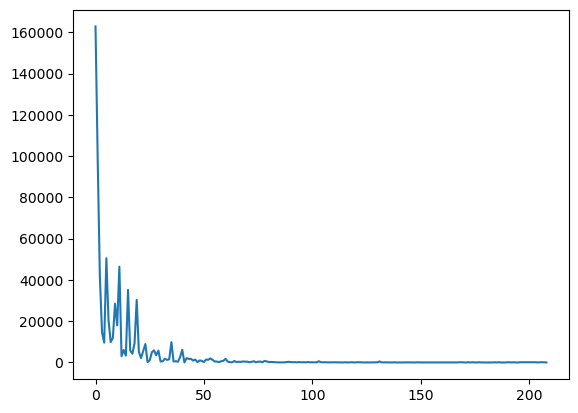

In [62]:

plt.plot(df["TotalDeaths"])

In [63]:
### Multi varient analysis
num_df = df.select_dtypes(include = 'number')
num_df

,Population,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop
0,3.311981e+08,5032179,162804.0,2576668.0,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0
1,2.127107e+08,2917562,98644.0,2047660.0,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0
2,1.381345e+09,2025409,41638.0,1377384.0,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0
3,1.459409e+08,871894,14606.0,676357.0,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0
4,5.938157e+07,538184,9604.0,387316.0,141264.0,539.0,9063.0,162.0,3149807.0,53044.0
...,...,...,...,...,...,...,...,...,...,...
204,4.992000e+03,13,1.0,10.0,2.0,27.5,2604.0,200.0,61.0,12220.0
205,2.624700e+04,13,113.0,7.0,6.0,27.5,495.0,29.0,424.0,16154.0
206,3.489000e+03,13,113.0,13.0,0.0,27.5,3726.0,29.0,1816.0,520493.0
207,8.010000e+02,12,113.0,12.0,0.0,27.5,14981.0,29.0,135702.0,32585.0


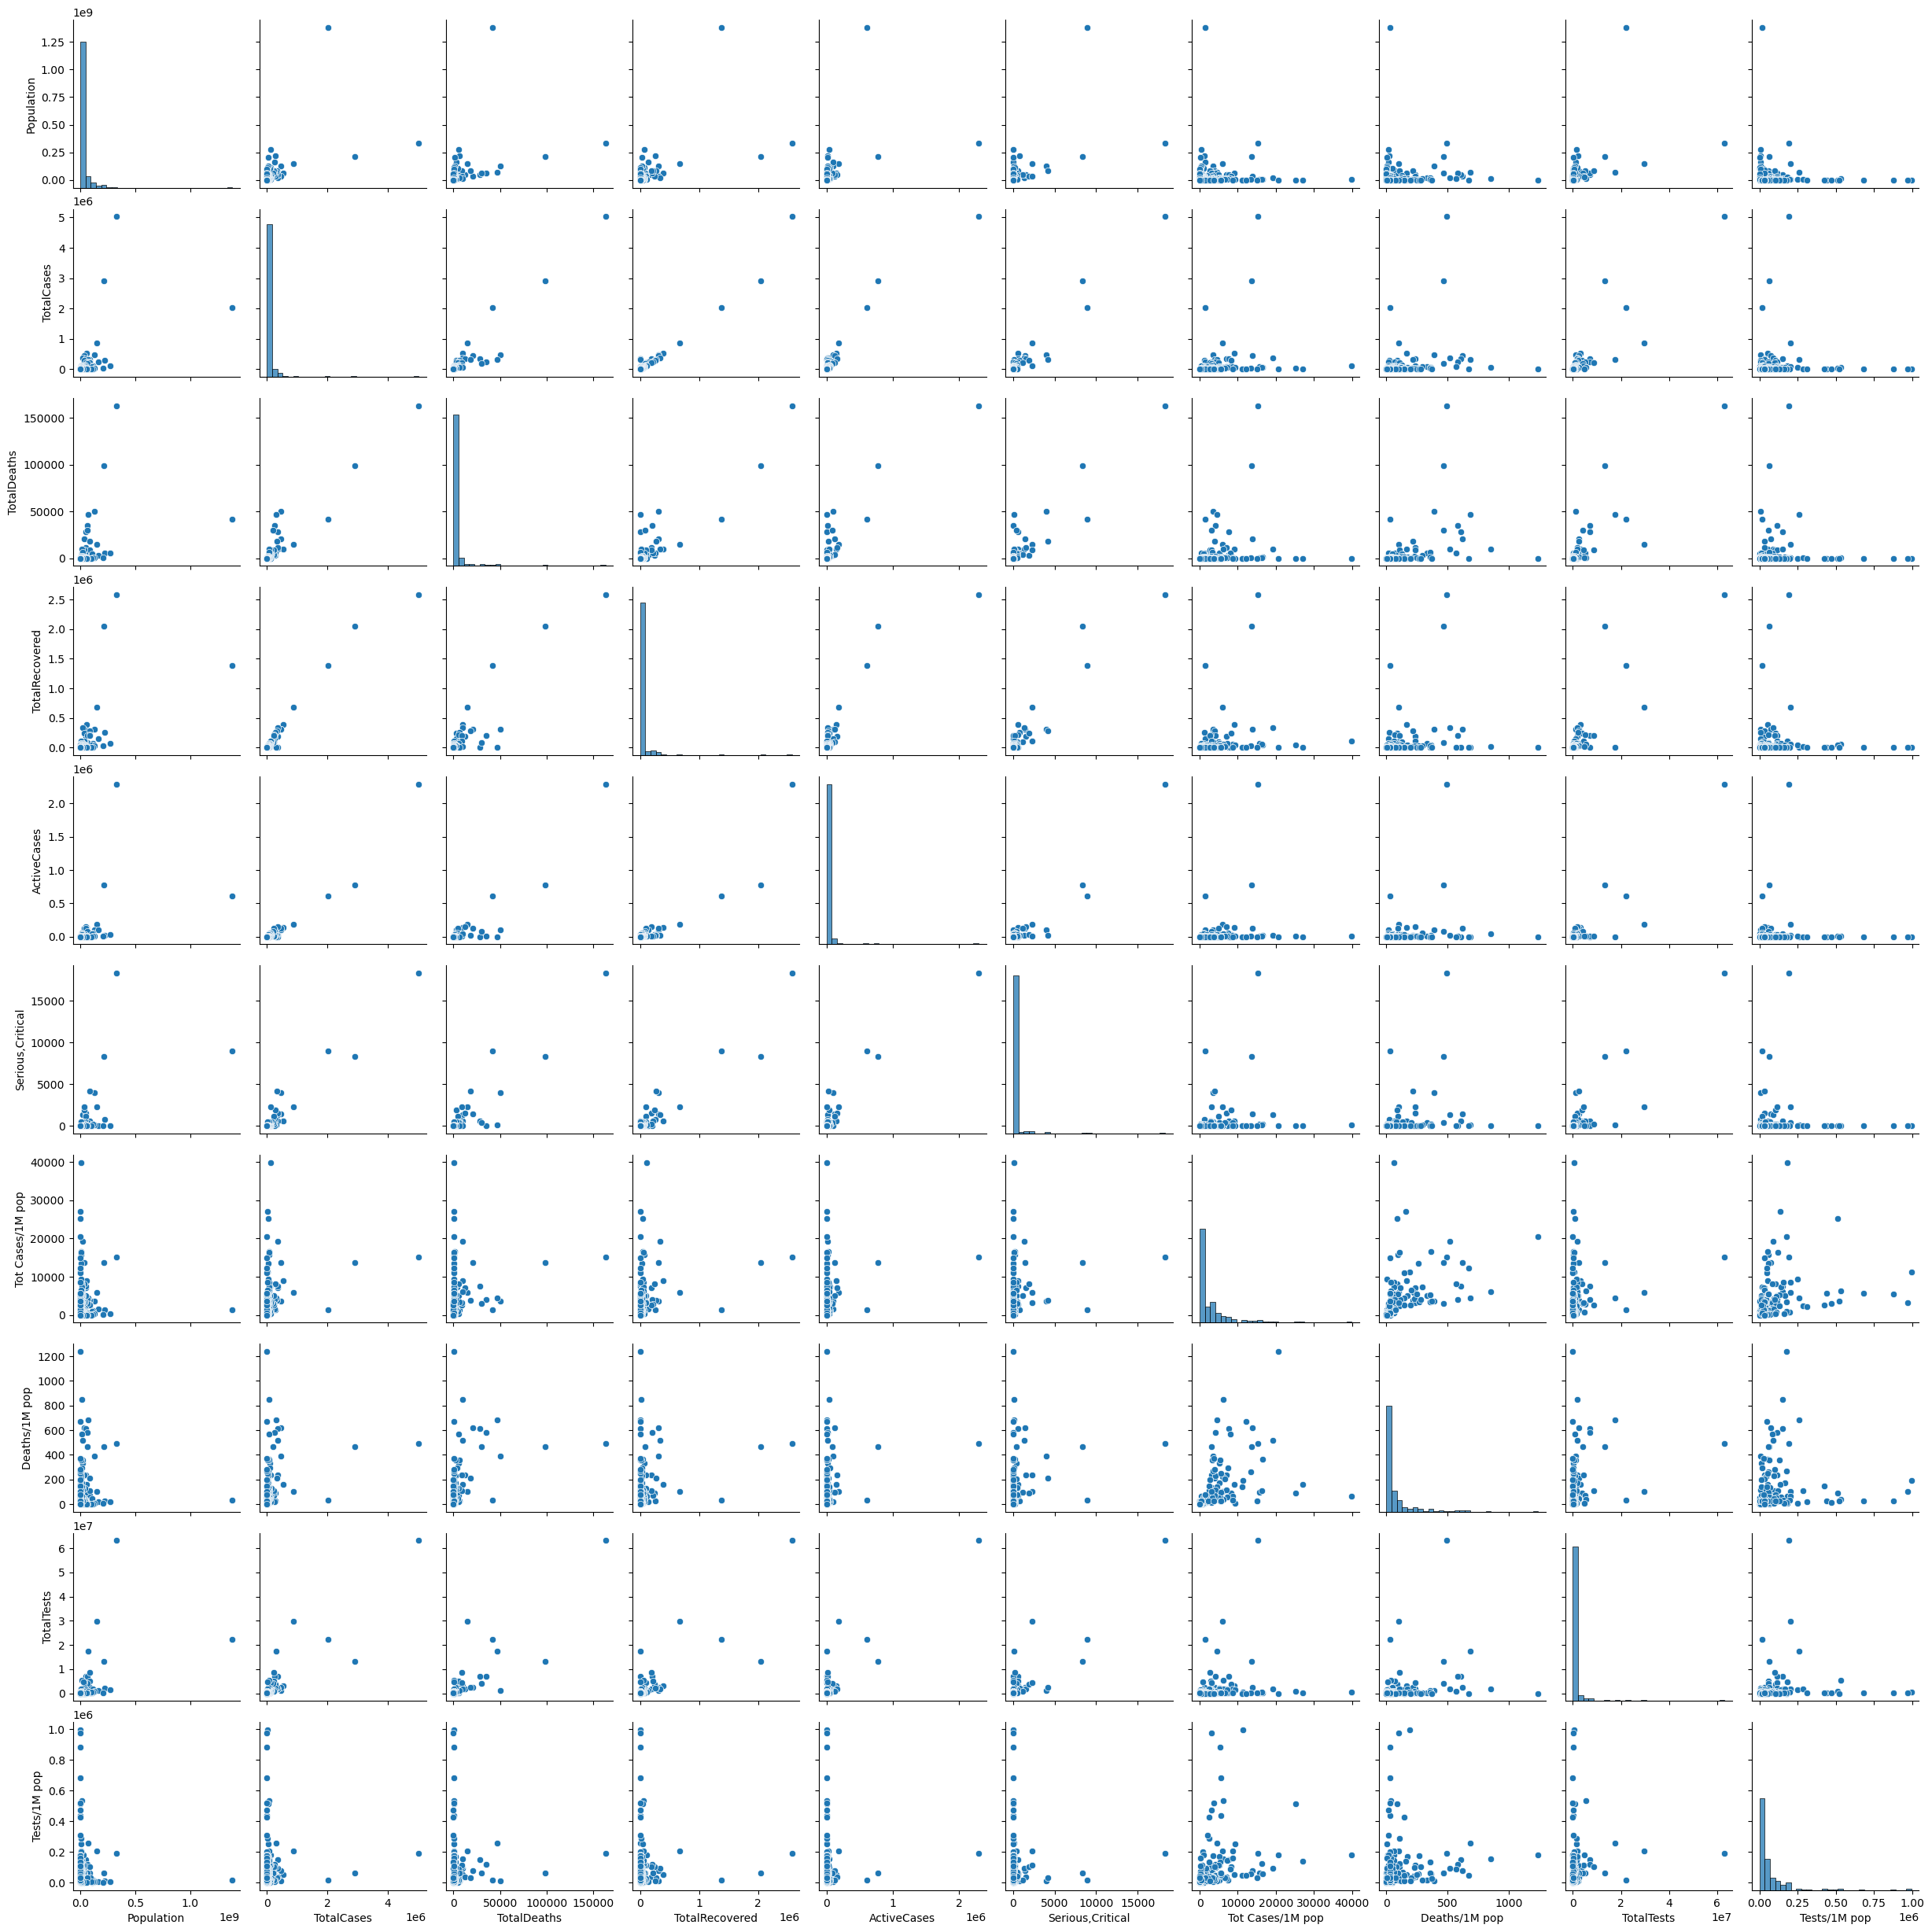

In [64]:
sns.pairplot(num_df)

<Axes: >

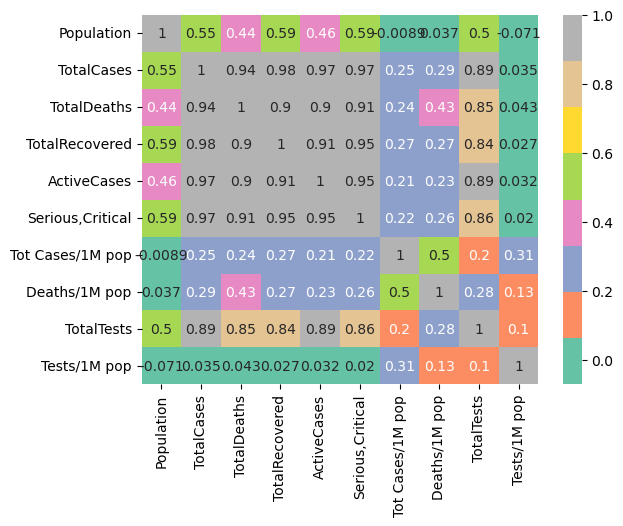

In [67]:
sns.heatmap(num_df.corr(),annot=True,cmap='Set2')

<Axes: xlabel='TotalRecovered', ylabel='Serious,Critical'>

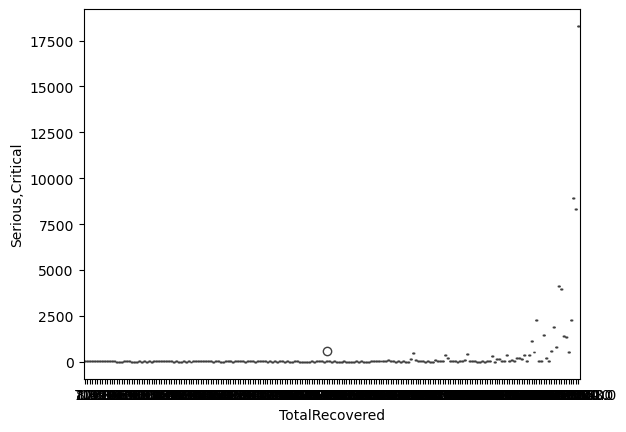

In [69]:
sns.boxplot(data=df,x='TotalRecovered',y='Serious,Critical')

<Axes: xlabel='TotalRecovered', ylabel='Count'>

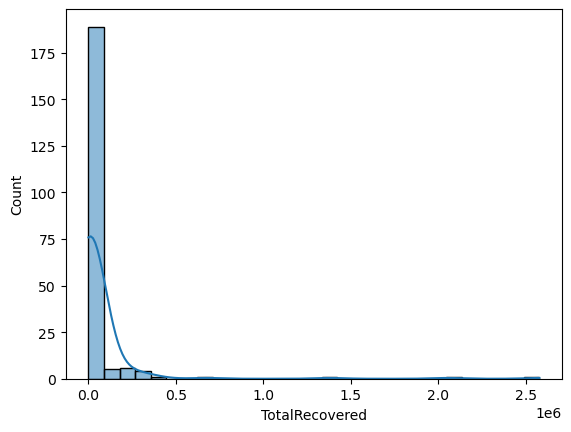

In [74]:
sns.histplot(data=df,x='TotalRecovered',kde=True)